# Introduction

Do higher film budgets lead to more box office revenue? Let's find out if there's a relationship using the movie budgets and financial performance data that I've scraped from [the-numbers.com](https://www.the-numbers.com/movie/budgets) on **May 1st, 2018**. 

<img src=https://i.imgur.com/kq7hrEh.png>

# Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Read the Data

In [7]:
data = pd.read_csv('cost_revenue_dirty.csv')
df = pd.DataFrame(data)

# Explore and Clean the Data

**Challenge**: Answer these questions about the dataset:
1. How many rows and columns does the dataset contain?
2. Are there any NaN values present?
3. Are there any duplicate rows?
4. What are the data types of the columns?

In [22]:
print(f"our data shape: {df.shape}")
print(f"rows: {int(df.shape[0])}, and cols: {df.shape[1]}")

display(df.info)

our data shape: (5391, 6)
rows: 5391, and cols: 6


<bound method DataFrame.info of       Rank Release_Date                     Movie_Title USD_Production_Budget  \
0     5293     8/2/1915           The Birth of a Nation              $110,000   
1     5140     5/9/1916                     Intolerance              $385,907   
2     5230   12/24/1916    20,000 Leagues Under the Sea              $200,000   
3     5299    9/17/1920  Over the Hill to the Poorhouse              $100,000   
4     5222     1/1/1925                  The Big Parade              $245,000   
...    ...          ...                             ...                   ...   
5386  2950    10/8/2018                             Meg           $15,000,000   
5387   126   12/18/2018                         Aquaman          $160,000,000   
5388    96   12/31/2020                     Singularity          $175,000,000   
5389  1119   12/31/2020          Hannibal the Conqueror           $50,000,000   
5390  2517   12/31/2020  Story of Bonnie and Clyde, The           $20,000,000

In [27]:
display(df.isna().any())

Rank                     False
Release_Date             False
Movie_Title              False
USD_Production_Budget    False
USD_Worldwide_Gross      False
USD_Domestic_Gross       False
dtype: bool

In [31]:
display(df.duplicated().any())
#to check for count of dupe rows:
display(len(df [ df.duplicated() ] ))

np.False_

0

In [25]:
display(df.dtypes)

Rank                      int64
Release_Date             object
Movie_Title              object
USD_Production_Budget    object
USD_Worldwide_Gross      object
USD_Domestic_Gross       object
dtype: object

In [46]:
df.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,1915-08-02,The Birth of a Nation,110000,11000000,10000000
1,5140,1916-05-09,Intolerance,385907,0,0
2,5230,1916-12-24,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,1920-09-17,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1925-01-01,The Big Parade,245000,22000000,11000000


### Data Type Conversions

**Challenge**: Convert the `USD_Production_Budget`, `USD_Worldwide_Gross`, and `USD_Domestic_Gross` columns to a numeric format by removing `$` signs and `,`. 
<br>
<br>
Note that *domestic* in this context refers to the United States.

In [47]:
money_cols = ['USD_Production_Budget', 'USD_Worldwide_Gross', 'USD_Domestic_Gross']
chars_to_rm = ["$", ","]
for col in money_cols:
    for char in chars_to_rm:
        df[col] = df[col].astype(str).str.replace(char, "")
    df[col] = pd.to_numeric(df[col], downcast='integer')
display(df.dtypes)

Rank                              int64
Release_Date             datetime64[ns]
Movie_Title                      object
USD_Production_Budget             int32
USD_Worldwide_Gross               int64
USD_Domestic_Gross                int32
dtype: object

**Challenge**: Convert the `Release_Date` column to a Pandas Datetime type. 

In [48]:
df.Release_Date = pd.to_datetime(df.Release_Date)
display(df.dtypes)

Rank                              int64
Release_Date             datetime64[ns]
Movie_Title                      object
USD_Production_Budget             int32
USD_Worldwide_Gross               int64
USD_Domestic_Gross                int32
dtype: object

### Descriptive Statistics

**Challenge**: 

1. What is the average production budget of the films in the data set?
2. What is the average worldwide gross revenue of films?
3. What were the minimums for worldwide and domestic revenue?
4. Are the bottom 25% of films actually profitable or do they lose money?
5. What are the highest production budget and highest worldwide gross revenue of any film?
6. How much revenue did the lowest and highest budget films make?

In [66]:
display(df.describe())
# 1. What is the average production budget of the films in the data set?
print(f"average production budget: {int(df.USD_Production_Budget.mean())}")
# 2. What is the average worldwide gross revenue of films?
print(f"average ww gross: {int(df.USD_Worldwide_Gross.mean())}")
# 3. What were the minimums for worldwide and domestic revenue?
print(f"min for ww revenue: {int(df.USD_Worldwide_Gross.min())}")
print(f"min for domestic revenue: {int(df.USD_Domestic_Gross.min())}")
# 4. Are the bottom 25% of films actually profitable or do they lose money?

# #df.describe already tells us this in a different format but below could also be used
# df['Net_Diff'] = df.USD_Worldwide_Gross - df.USD_Production_Budget
# df_sorted_by_diff = df.sort_values(by='Net_Diff', ascending=True)
# qtr_ct = int(len(df)/4)
# df_sorted_by_diff.Net_Diff[:qtr_ct]

# 5. What are the highest production budget and highest worldwide gross revenue of any film?
print(f"highest prd budget: {df.USD_Production_Budget.max()}")
print(f"highest ww gross: {df.USD_Worldwide_Gross.max()}")
# 6. How much revenue did the lowest and highest budget films make?
df_budget = df.sort_values('USD_Production_Budget', ascending=True)
movie_lowest_budget = df_budget.iloc[0]
movie_highest_budget = df_budget.iloc[-1]
print(f"movie with lowest budget was {movie_lowest_budget.Movie_Title} and made {movie_lowest_budget.USD_Worldwide_Gross}")
print(f"movie with highest budget was {movie_highest_budget.Movie_Title} and made {movie_highest_budget.USD_Worldwide_Gross}")

,Rank,Release_Date,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Net_Diff
count,"5,391.00",5391,"5,391.00","5,391.00","5,391.00","5,391.00"
mean,"2,696.00",2003-09-19 15:02:02.203672704,"31,113,737.58","88,855,421.96","41,235,519.44","57,741,684.38"
min,1.00,1915-08-02 00:00:00,"1,100.00",0.00,0.00,"-175,000,000.00"
25%,"1,348.50",1999-12-02 12:00:00,"5,000,000.00","3,865,206.00","1,330,901.50","-2,244,775.00"
50%,"2,696.00",2006-06-23 00:00:00,"17,000,000.00","27,450,453.00","17,192,205.00","8,122,000.00"
75%,"4,043.50",2011-11-23 00:00:00,"40,000,000.00","96,454,455.00","52,343,687.00","59,518,660.00"
max,"5,391.00",2020-12-31 00:00:00,"425,000,000.00","2,783,918,982.00","936,662,225.00","2,358,918,982.00"
std,"1,556.39",NaN,"40,523,796.88","168,457,757.00","66,029,346.27","140,972,329.93"


average production budget: 31113737
average ww gross: 88855421
min for ww revenue: 0
min for domestic revenue: 0
highest prd budget: 425000000
highest ww gross: 2783918982
movie with lowest budget was My Date With Drew and made 181041
movie with highest budget was Avatar and made 2783918982


# Investigating the Zero Revenue Films

**Challenge** How many films grossed $0 domestically (i.e., in the United States)? What were the highest budget films that grossed nothing?

In [68]:
df_zero_domestic_gross = df[df.USD_Domestic_Gross == 0]
print("num of films with $0 domestic gross: ", len(df_zero_domestic_gross))
print("highest budget film with $0 gross: ", df_zero_domestic_gross.USD_Production_Budget.max())

num of films with $0 domestic gross:  512
highest budget film with $0 gross:  175000000


**Challenge**: How many films grossed $0 worldwide? What are the highest budget films that had no revenue internationally?

In [70]:
df_zero_ww_gross = df[df.USD_Worldwide_Gross == 0]
print("num of films with $0 ww gross: ", len(df_zero_ww_gross))
print("movies with $0 ww gross and highest budget:")
display(df_zero_ww_gross.sort_values('USD_Production_Budget', ascending=False).head(5))

num of films with $0 ww gross:  357
movies with $0 ww gross and highest budget:


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Net_Diff
5388,96,2020-12-31,Singularity,175000000,0,0,-175000000
5387,126,2018-12-18,Aquaman,160000000,0,0,-160000000
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0,-103000000
5385,366,2018-10-08,Amusement Park,100000000,0,0,-100000000
5058,880,2015-11-12,The Ridiculous 6,60000000,0,0,-60000000


### Filtering on Multiple Conditions

In [74]:
#which films made money internationally (i.e., data.USD_Worldwide_Gross != 0), 
#but had zero box office revenue in the United States (i.e., data.USD_Domestic_Gross == 0)? 
df_cond = df.loc[(df.USD_Worldwide_Gross != 0) & (df.USD_Domestic_Gross == 0)]
df_cond

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Net_Diff
71,4310,1956-02-16,Carousel,3380000,3220,0,-3376780
1579,5087,2001-02-11,Everything Put Together,500000,7890,0,-492110
1744,3695,2001-12-31,The Hole,7500000,10834406,0,3334406
2155,4236,2003-12-31,Nothing,4000000,63180,0,-3936820
2203,2513,2004-03-31,The Touch,20000000,5918742,0,-14081258
...,...,...,...,...,...,...,...
5340,1506,2017-04-14,Queen of the Desert,36000000,1480089,0,-34519911
5348,2225,2017-05-05,Chāi dàn zhuānjiā,23000000,58807172,0,35807172
5360,4832,2017-07-03,Departure,1100000,27561,0,-1072439
5372,1856,2017-08-25,Ballerina,30000000,48048527,0,18048527


**Challenge**: Use the [`.query()` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.query.html) to accomplish the same thing. Create a subset for international releases that had some worldwide gross revenue, but made zero revenue in the United States. 

Hint: This time you'll have to use the `and` keyword.

In [78]:
df_sub_cond = df.query('(USD_Worldwide_Gross != 0) and (USD_Domestic_Gross == 0)')
df_sub_cond

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Net_Diff
71,4310,1956-02-16,Carousel,3380000,3220,0,-3376780
1579,5087,2001-02-11,Everything Put Together,500000,7890,0,-492110
1744,3695,2001-12-31,The Hole,7500000,10834406,0,3334406
2155,4236,2003-12-31,Nothing,4000000,63180,0,-3936820
2203,2513,2004-03-31,The Touch,20000000,5918742,0,-14081258
...,...,...,...,...,...,...,...
5340,1506,2017-04-14,Queen of the Desert,36000000,1480089,0,-34519911
5348,2225,2017-05-05,Chāi dàn zhuānjiā,23000000,58807172,0,35807172
5360,4832,2017-07-03,Departure,1100000,27561,0,-1072439
5372,1856,2017-08-25,Ballerina,30000000,48048527,0,18048527


### Unreleased Films

**Challenge**:
* Identify which films were not released yet as of the time of data collection (May 1st, 2018).
* How many films are included in the dataset that have not yet had a chance to be screened in the box office? 
* Create another DataFrame called df_clean that does not include these films. 

In [81]:
# Date of Data Collection
scrape_date = pd.Timestamp('2018-5-1')

In [88]:
df_unreleased = df.query('Release_Date > @scrape_date')
print(f"num of movies in dataset that haven't been released: {len(df_unreleased)}")
df_clean = df.drop(df_unreleased.index)
print("after dropping unreleased movies, we have: ", df_clean.shape[0] , " rows")

num of movies in dataset that haven't been released: 7
after dropping unreleased movies, we have:  5384  rows


### Films that Lost Money

**Challenge**: 
What is the percentage of films where the production costs exceeded the worldwide gross revenue? 

In [120]:
out_the_money = df.query('Net_Diff < 0')
percent_out_the_money = f"{(len(out_the_money) / len(df_clean)) * 100 :.3f}%"
percent_out_the_money

print(f"in this dataset, we see that {percent_out_the_money} of films do not " + 
      f"recoup their production budget at the box office.")

in this dataset, we see that 37.407% of films do not recoup their production budget at the box office.


# Seaborn for Data Viz: Bubble Charts

### Plotting Movie Releases over Time

**Challenge**: Try to create the following Bubble Chart:

<img src=https://i.imgur.com/8fUn9T6.png>



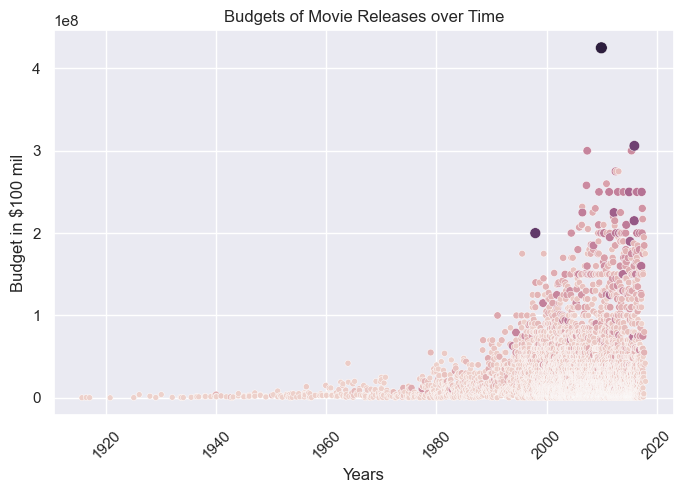

In [160]:
#if we already didn't have our data loaded, we could do:
#sns.load_dataset()

sns.scatterplot(df_clean, x = 'Release_Date', y = 'USD_Production_Budget',
                size = 'USD_Worldwide_Gross', hue = 'USD_Worldwide_Gross',
                legend = 'auto',
               )
plt.legend().set_title("Worldwide Gross Revenue")
plt.xlabel('Years')
plt.ylabel('Budget in $100 mil')
plt.title('Budgets of Movie Releases over Time')

#can remove legend with:
plt.legend().remove()
#adjust xticks for fun with angle:
plt.xticks(rotation=45)
#update figure size and scale
sns.set_theme(rc={'figure.figsize':(8,5)})

In [ ]:
#could have also done something like below:
plt.figure(figsize=(8,4), dpi=200)
 
with sns.axes_style("darkgrid"):
    ax = sns.scatterplot(data=df_clean, 
                    x='Release_Date', 
                    y='USD_Production_Budget',
                    hue='USD_Worldwide_Gross',
                    size='USD_Worldwide_Gross',)
    ax.set(ylim=(0, 450000000),
       xlim=(data_clean.Release_Date.min(), df_clean.Release_Date.max()),
       xlabel='Year',
       ylabel='Budget in $100 millions')

# Converting Years to Decades Trick

**Challenge**: Create a column in `data_clean` that has the decade of the release. 

<img src=https://i.imgur.com/0VEfagw.png width=650> 

Here's how: 
1. Create a [`DatetimeIndex` object](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DatetimeIndex.html) from the Release_Date column. 
2. Grab all the years from the `DatetimeIndex` object using the `.year` property.
<img src=https://i.imgur.com/5m06Ach.png width=650>
3. Use floor division `//` to convert the year data to the decades of the films.
4. Add the decades as a `Decade` column to the `data_clean` DataFrame.

In [281]:
df_clean['Year'] = pd.DatetimeIndex(df_clean.Release_Date).year
df_clean['Decade'] = pd.to_numeric((df_clean['Year'] // 10 ) * 10)
#could also do below instead of above two linw but having both year and decade column felt better:
# df_clean['Decade'] = (df_clean['Release_Date'].dt.year // 10) * 10
df_clean.sample(3)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Net_Diff,Decade,Year
1366,1175,1999-12-24,Galaxy Quest,45000000,90523726,71423726,45523726,1990,1999
24,4556,1940-01-01,Boom Town,2000000,9172000,9172000,7172000,1940,1940
3867,1803,2011-04-02,Sanctum,30000000,104283753,23209310,74283753,2010,2011


### Separate the "old" (before 1969) and "New" (1970s onwards) Films

**Challenge**: Create two new DataFrames: `old_films` and `new_films`
* `old_films` should include all the films before 1969 (up to and including 1969)
* `new_films` should include all the films from 1970 onwards
* How many films were released prior to 1970?
* What was the most expensive film made prior to 1970?

In [188]:
yr_cutoff = pd.Timestamp('1970-1-1')
old_films = df_clean[df_clean.Decade < yr_cutoff]
new_films = df_clean[df_clean.Decade >= yr_cutoff]

In [ ]:
print(f"num of films released prior to 1970: {len(old_films)}")
print(f"num of films released after 1970: {len(new_films)}")

In [206]:
# # (works but inefficient)
# max_budget = old_films.USD_Production_Budget.max()
# expensive_film = old_films[old_films.USD_Production_Budget == max_budget]

# Better
most_expensive_idx = old_films['USD_Production_Budget'].idxmax()
most_expensive = old_films.loc[most_expensive_idx]

print(f"most expensive film prior to 1970: {most_expensive['Movie_Title']} " + 
      f"with budget of: {most_expensive['USD_Production_Budget']}")

most expensive film prior to 1970: Cleopatra with budget of: 42000000


In [209]:
#could also describe or sort as well:
old_films.USD_Production_Budget.describe()

old_films.sort_values(by='USD_Production_Budget', ascending=False).head(5)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Net_Diff,Decade,Year
109,1253,1963-12-06,Cleopatra,42000000,71000000,57000000,29000000,1960,1963
150,2175,1969-12-16,"Hello, Dolly",24000000,33208099,33208099,9208099,1960,1969
143,2465,1969-01-01,Sweet Charity,20000000,8000000,8000000,-12000000,1960,1969
118,2425,1965-02-15,The Greatest Story Ever Told,20000000,15473333,15473333,-4526667,1960,1965
148,2375,1969-10-15,Paint Your Wagon,20000000,31678778,31678778,11678778,1960,1969


# Seaborn Regression Plots

**Challenge**: Use Seaborn's `.regplot()` to show the scatter plot and linear regression line against the `new_films`. 
<br>
<br>
Style the chart

* Put the chart on a `'darkgrid'`.
* Set limits on the axes so that they don't show negative values.
* Label the axes on the plot "Revenue in \$ billions" and "Budget in \$ millions".
* Provide HEX colour codes for the plot and the regression line. Make the dots dark blue (#2f4b7c) and the line orange (#ff7c43).

Interpret the chart

* Do our data points for the new films align better or worse with the linear regression than for our older films?
* Roughly how much would a film with a budget of $150 million make according to the regression line?

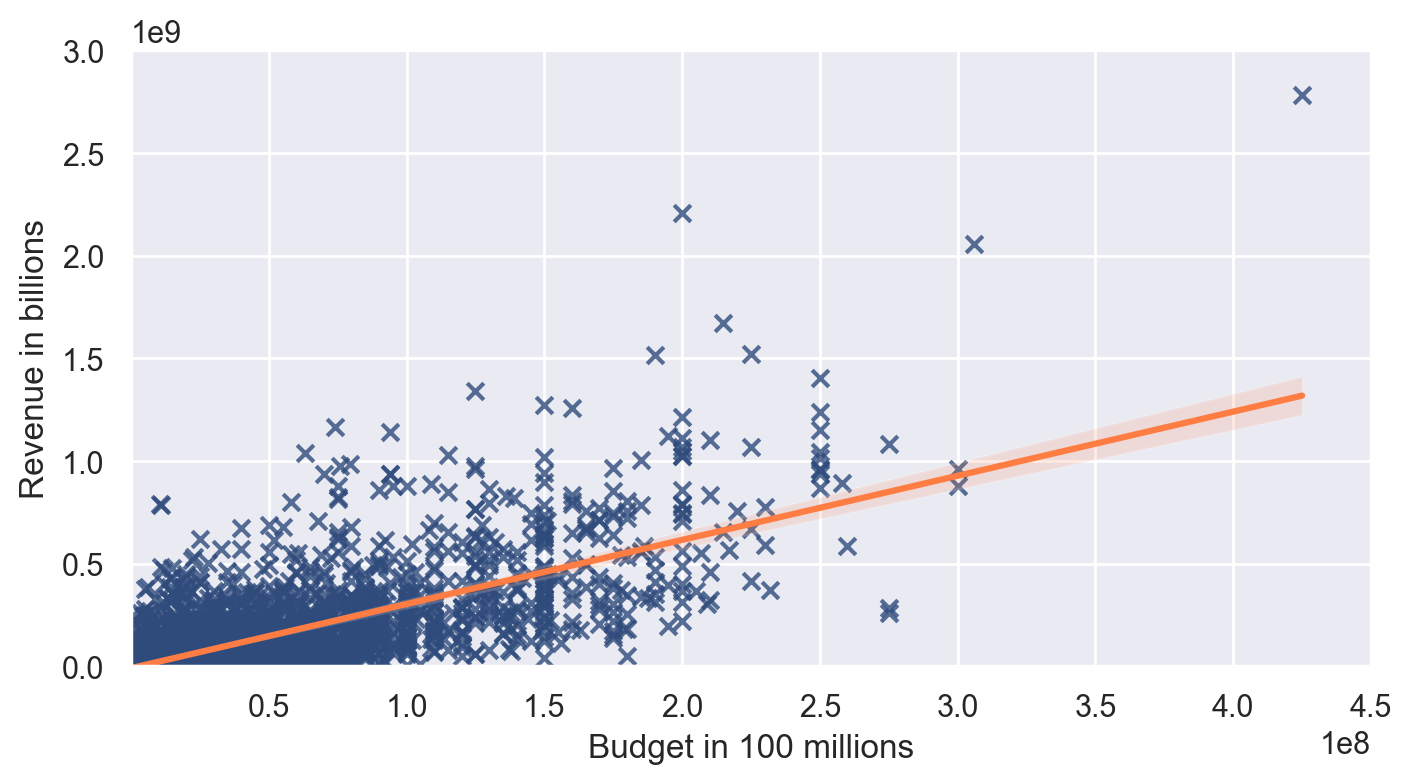

In [231]:
plt.figure(figsize=(8,4), dpi=200)
 
with sns.axes_style("darkgrid"):
    ax = sns.regplot(new_films, 
                    x='USD_Production_Budget', 
                    y='USD_Worldwide_Gross',
                    marker = 'x', 
                    scatter_kws = dict(color="#2f4b7c"),
                    line_kws = dict(color="#ff7c43"),
                    )
    ax.set(ylim=(0, 3e9), #3e9 for scientific notation for 3 billions
       xlim=(new_films.USD_Production_Budget.min(), 4.5e8), #sci not for 450 mil
       xlabel='Budget in 100 millions',
       ylabel='Revenue in billions')

# Run Your Own Regression with scikit-learn

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

In [234]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [235]:
# sklearn requires 2D input for X (features)
# Single bracket returns Series (1D): shape (5231,)
# Double bracket returns DataFrame (2D): shape (5231, 1)

# Use double brackets for 2D shape
X = new_films[['USD_Production_Budget']]  # (5231, 1)
y = new_films['USD_Worldwide_Gross']      # (5231,) - 1D is fine for target

# Multiple features: just add more columns
# X = new_films[['USD_Production_Budget', 'USD_Domestic_Gross']]  # (5231, 2)

**Challenge**: Run a linear regression for the `old_films`. Calculate the intercept, slope and r-squared. How much of the variance in movie revenue does the linear model explain in this case?

In [237]:
X = old_films[['USD_Production_Budget']]
y = old_films[['USD_Worldwide_Gross']]

model = reg.fit(X,y)

In [240]:
print(model.coef_)
print(model.intercept_)

[[1.64771314]]
[22821538.63508039]


# Use Your Model to Make a Prediction

We just estimated the slope and intercept! Remember that our Linear Model has the following form:

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

**Challenge**:  How much global revenue does our model estimate for a film with a budget of $350 million? 

In [270]:
budget = 350_000_000
prediction = model.predict(pd.DataFrame([[budget]], columns = ['USD_Production_Budget'])).flatten()[0]
print(f"Revenue prediction for ${budget:,} budget: ${int(prediction):,}")

Revenue prediction for $350,000,000 budget: $599,521,139


In [280]:
#could also do something like this using reg:
budget = 350_000_000
revenue_est = round(reg.intercept_[0] + reg.coef_[0,0] * budget, 2)
print(f'The estimated revenue for a $350 film is around ${revenue_est:,}.')

The estimated revenue for a $350 film is around $599,521,139.04.
